**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from BestFit.

# 00. Getting Started with RMC-BestFit in Python
Welcome! This notebook will guide you through setting up and using the USACE-RMC BestFit library in Python via PythonNet.

## What You Will Learn
- What the BestFit library provides and where it fits in the workflow
- How to obtain or load `Numerics.dll` and `RMC.BestFit.dll`
- How to load the correct .NET runtime with PythonNet and add the DLL reference from Python
- How to convert Python data to .NET objects
- Build a BestFit model

## Virtual Python Environment
Before we get to BestFit, we need to ensure Python is up and running on your device and in these notebooks. In the top right hand corner of this notebook click on the **"Select Kernel"** button. A Python environment should be available for you to chose from, assuming you've downloaded Python. If you have Python on your computer, but cannot find a Python kernel to select, don't worry we have a solution. We will create and virtual Python environment just for this library to work with.

This virtual Python environment will give this library its own copy of Python, its own set of tools and libraries, and keep it isolated from other projects. Before we start, please ensure you have the newest version of Python installed locally on your device.

1. Open a new terminal and make sure it is pointing to your project folder (you should see the folder path in the prompt)
2. To create the virtual environment, run one of the commands below:        
   ```bash 
   # Mac/Linux
   python3 -m venv .venv
   # Windows
   python -m venv .venv
   ```
   This will create the .venv folder in your project. Double check that you can see this folder in the file explorer now.
3. Now we will activate the virtual environment:
   ```bash
   # Mac/Linux
   source .venv/bin/activate
   # Windows (Command Prompt)
   .venv\Scripts\activate.bat
   # Windows (PowerShell)
   .venv\Scripts\Activate.ps1
   ```
   You should now see `(.venv)` appear at the start of the terminal prompt. This means it's active!
4. Install ipykernel. This is what allows Jupyter to see your virtual environment as a kernel. With the `.venv` active run:
   ```bash
   pip install ipykernel
   ```
   Then register it: 
   ```bash
   # Mac/Linux
   python3 -m ipykernel install --user --name=.venv --display-name "Python (.venv)"
   # Windows
   python -m ipykernel install --user --name=.venv --display-name "Python (.venv)"
   ```
5. Now you should be able to select this virtual environment as a kernel. Click on the **"Select Kernel"** in the top right. Chose Python environments and select Python(.venv), the one you just created! If it doesn't show up right away, try reloading your window.
6. Open the command palette (Ctrl+Shift+P or Cmd+Shift+P) and find **"Python:Select Interpreter"**. Chose the .venv option to tell VS code to always use this interpreter going forward.

Now we have ensured that we can use and run Python in these Jupyter notebooks. Time to get down to business in BestFit!

## What is BestFit?
RMC-BestFit is a state-of-the-art Bayesian estimation and fitting software developed collaboratively by the U.S. Army Corps of Engineers' Risk Management Center (RMC) and Engineer Research and Development Center's Coastal and Hydraulics Laboratory (CHL). Tailored to expedite flood hazard assessments for the Flood Risk Management, Planning, and Dam and Levee Safety communities, the software employs a Bayesian framework to integrate a variety of data sources, including historical records, paleoflood evidence, regional data, rainfall-runoff models, and expert judgment. This intuitive application provides a comprehensive environment for distribution fitting and Bayesian estimation. It includes:
- Various data import methods
- Advanced hypothesis testing
- Probability distributions
- Nonstationary flood frequency analysis
- Complex modeling techniques
- Dependency modeling

The best way to understand BestFit is to start with the general risk equation:
$$ 
\text{Risk} = P(\text{Hazard}) \times P(\text{Failure} \mid \text{Hazard}) \times \text{Consequence} \mid \text{Failure}
$$

BestFit helps determine flood hazard, often in conjunction with the RMC’s Reservoir Frequency Analysis (RMC-RFA) software. In flood hazard analysis, BestFit evaluates volume-frequency relationships using inflow volumes, peak-to-volume ratios, and rating curves. These depend on the critical duration of a watershed, which is the period during which flow is highest [[1]](#1). Then we have:

$$
\text{Inflow Volume} = \frac{\text{Average Flow Rate}}{\text{Critical Duration}}
$$

$$
\text{Peak-to-Volume Ratio} = \frac{\text{Instantaneous Peak}}{\text{Max N Day Volume}}
$$

These relationships are invertible. For instance, if we have a peak-to-volume ratio we can estimate the volume of the watershed:
$$
\text{Estimated Volume Over N Days} = \frac{\text{Discharge (cfs)}}{\text{Average Peak-to-Volume Ratio Over N Days}}
$$

These are the basic concepts we seek to understand with BestFit. Through this demo keep these in the back of your head and think about where they can be calculated or used in each notebook.

## Obtaining BestFit from the USACE-RMC GitHub Page
There are 3 recommend ways to obtain BestFit.

### Option 1: Download the Repository Directly

1. Visit the [USACE-RMC/RMC-BestFit GitHub repository](https://github.com/USACE-RMC/RMC-BestFit)
2. Click the green **"Code"** button and select **"Download ZIP"**
3. Extract the ZIP file to a location on your computer
4. Build the solution (requires Visual Studio or .NET SDK):
   ```bash
   cd RMC-BestFit
   dotnet build RMC-BestFit.sln --configuration Release
   ```
5. The compiled `RMC.BestFit.dll` will be in `RMC-BestFit/Libraries/Release/RMC.BestFit.dll` (or similar)

### Option 2: Clone with Git (Recommended for Auto-Updates)

This approach allows you to easily pull the latest changes without re-downloading everything.

1. Install Git (if not already installed): [git-scm.com](https://git-scm.com/)
2. Clone the repository:
   ```bash
   git clone https://github.com/USACE-RMC/RMC-BestFit
   cd RMC-BestFit
   ```
3. Build the DLL:
   ```bash
   dotnet build RMC-BestFit.sln --configuration Release
   ```
4. Update to latest version anytime:
   ```bash
   cd RMC-BestFit  # Navigate to the cloned directory
   git pull origin main  # Pull latest changes
   dotnet build RMC-BestFit.sln --configuration Release  # Rebuild

### Option 3: Download RMC-BestFit from USACE-RMC Website
If you've used BestFit in the past, you may already have the software on your computer. To ensure it is the latest version visit, the [RMC Software page](https://www.rmc.usace.army.mil/Software/RMC-BestFit/). From here you can double check the latest available version and download it should yours be out of date. Once downloaded, open the application to ensure everything is running smoothly. 


This demo also uses methods from RMC-Numerics. When downloading RMC-BestFit, the software automatically comes with the Numerics.dll inside, so you should be good to go. Once you find the RMC.BestFit.dll, your Numerics.dll will be in the same folder. To learn more about using Numerics in Python check out [Numerics-Python-Examples](https://github.com/USACE-RMC/Numerics-Python-Examples). We recommend completing the Numerics Python demo before this one, but it is not required. You can download Numerics separately and reference the standalone .dll for it, but it is just another step.

## Prerequisites
Before running this notebook, ensure you have:
1. .NET Runtime (6.0+ or .NET Framework 4.8.1 on Windows)
2. Python 3.8+
3. Required packages (install via pip). See ```notebook-requirements.txt``` for the full list of external python packages you need to install to run all of the notebooks.

Now that you have BestFit and Numerics up and running the core workflow is: 
1. Load the .NET runtime.
2. Add the BestFit and Numerics DLL references.
3. Import namespaces and use Numerics as if it were a native Python library.

## Step 1: Load the .NET Runtime.
**CRITICAL:** You must load the .NET runtime before importing `clr`. This is the most common setup mistake.

Runtime selection:
- Use `pythonnet.load("coreclr")` for .NET 6/7/8.
- Use `pythonnet.load("netfx")` only for .NET Framework (Windows-only).

If you're not sure which you have installed, check the Numerics build output folder (e.g., `net8.0` indicates CoreCLR).


In [25]:
import pythonnet

# Use CoreCLR for the current RMC-BestFit .NET build.
# Switch to netfx only if you intentionally use a .NET Framework build.
pythonnet.load("coreclr")

print("✓ .NET runtime loaded")

✓ .NET runtime loaded


## Step 2: Import clr and Load DLLs

Now we can import the CLR bridge and load the BestFit and Numerics assemblies. A lot of BestFit methods are built off of the Numerics library and require Numerics objects to be passed to them. When you download BestFit, it should come with both the RMC.BestFit.dll and Numerics.dll under the Libraries folder. We are using the latest version of BestFit Version 2.0 (Beta-3).

This repository also comes with two built in helper functions to find your respective DLLs, `resolve_bestfit-dll()` and `resolve_numerics_dll()`.

How DLL helpers work:
- `resolve_bestfit_dll()` checks `RMC_BESTFIT_DLL`, a global variable users can set with the direct path to the DLL, first, then known local fallback paths, and returns the first existing file.
- `resolve_numerics_dll()` does the same for `RMC_NUMERICS_DLL`.
- If no valid file is found, each function raises a clear `FileNotFoundError` so you can fix pathing immediately.

In [26]:
import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

✓ Numerics loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\Numerics.dll
✓ BestFit loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\RMC.BestFit.dll


## Step 3: Import Namespaces
Now we can import classes from Numerics and BestFit just like any other Python module. Be sure to check how the namespaces are organized within each library. Below we import the namespaces needed for a handful of basic examples.

In [38]:
from RMC.BestFit import ExactData
from RMC.BestFit.Models import DataFrame, UnivariateDistribution
from RMC.BestFit.Estimation import MaximumLikelihood

from Numerics.Distributions import UnivariateDistributionType, Gumbel, Normal, LogNormal
from Numerics.Sampling.MCMC import LogLikelihood 
from Numerics.Data.Statistics import Correlation

from System import Array, Double

print("✓ Imported namespaces successfully")

✓ Imported namespaces successfully


### Looking At Assemblies and Namespaces

It can be hard to navigate the namespaces and classes within BestFit. We recommend opening BestFit in Visual Studio Community and using the solution explorer to navigate the code. But you can also pull the namespaces and class from right here in VS Code by accessing the assemblies loaded in the .dll.

An assembly is a complied code library that is physically stored inside a .dll. When we load and use the .dll file we are interacting with the .NET assembly. The code below is an example of how we can access namespaces and classes [[2]](#2).

In [28]:
import sys
from System.Reflection import Assembly

# Pull the BestFit assembly to inspect its types and namespaces
assembly = Assembly.LoadFrom(str(resolve_bestfit_dll()))

# List all namespaces
namespaces = set()
for typ in assembly.GetTypes():
    ns = typ.Namespace # Get the namespace of the type, if it exists
    if ns and ('BestFit' in ns or 'RMC' in ns):  # Filter relevant namespaces we want to look at
        namespaces.add(ns)

print("Relevant Namespaces:")
for ns in sorted(namespaces):
    print(f"- {ns}")

# List classes in a specific namespace (e.g., RMC.BestFit)
target_ns = 'RMC.BestFit'  # Adjust as needed
classes = [t.FullName for t in assembly.GetTypes() if t.Namespace == target_ns]  # Pull names for classes in the target namespace
print("\nClasses in RMC.BestFit:")
for cls in sorted(classes):
    print(f"- {cls}")

# Now we can look for types that might be related to fitting analysis based on their names and namespaces
types = assembly.GetTypes()
keywords = ["FittingAnalysis", "FitAnalysis", "Fitting", "Fit"]
candidates = [
    t for t in types
    if t.Name is not None and any(k in t.Name for k in keywords)
]

# Function to determine the kind of type (class, interface, enum, etc.)
def type_kind(t):
    if t.IsEnum:
        return "Enum"
    if t.IsInterface:
        return "Interface"
    if t.IsClass and t.IsAbstract and t.IsSealed:
        return "Static Class"
    if t.IsClass and t.IsAbstract:
        return "Abstract Class"
    if t.IsClass:
        return "Class"
    if t.IsValueType:
        return "Struct"
    return "Other"


print("=== Possible fitting-analysis types ===")
for t in sorted(candidates, key=lambda x: x.FullName):
    print(f"{t.FullName} [{type_kind(t)}]")

# If you want to restrict to RMC.BestFit namespaces:
print("\n=== Within RMC.BestFit* only ===")
for t in sorted(types, key=lambda x: x.FullName):
    ns = t.Namespace or ""
    if ns.startswith("RMC.BestFit") and any(k in t.Name for k in keywords):
        print(f"{t.FullName} [{type_kind(t)}]")

Relevant Namespaces:
- RMC.BestFit
- RMC.BestFit.Analyses
- RMC.BestFit.Diagnostics
- RMC.BestFit.Estimation
- RMC.BestFit.Models
- RMC.BestFit.Models.LinkFunctions
- RMC.BestFit.Models.SpatialExtremes
- RMC.BestFit.Models.TrendFunctions
- RMC.BestFit.Models.TrendFunctions.Support

Classes in RMC.BestFit:
- RMC.BestFit.Data
- RMC.BestFit.DataSeries
- RMC.BestFit.DataSeries+<>c
- RMC.BestFit.ExactData
- RMC.BestFit.ExactSeries
- RMC.BestFit.ExactSeries+<>c
- RMC.BestFit.IntervalData
- RMC.BestFit.IntervalSeries
- RMC.BestFit.IntervalSeries+<>c
- RMC.BestFit.ThresholdData
- RMC.BestFit.ThresholdSeries
- RMC.BestFit.ThresholdSeries+<>c
- RMC.BestFit.UncertainData
- RMC.BestFit.UncertainSeries
- RMC.BestFit.UncertainSeries+<>c
=== Possible fitting-analysis types ===
RMC.BestFit.Analyses.FittingAnalysis [Class]
RMC.BestFit.Models.FittedDistribution [Class]
RMC.BestFit.Models.LinkFunctions.BestFitLinkFunctionFactory [Static Class]

=== Within RMC.BestFit* only ===
RMC.BestFit.Analyses.Fittin

## Working with .NET Arrays
Many BestFit and Numerics methods require .NET arrays instead of Python lists. Here's how we can convert between them. There is also helper functions in `notebooks/helper_functions.py`: `convert_to_dotnet_array(pythonList)`. Throughout this notebook we will continue to cover these kinds of conversion. When creating your own BestFit projects in Python, if a method fails, that first thing you should do is double check that you are passing the right type of data to it.

In [29]:
# Python list to .NET Array[Double]
python_data = [10.5, 20.3, 15.7, 18.9, 22.1]
dotnet_array = Array[Double](python_data)

print(f"Python list: {python_data}")
# Accessing .NET array elements since Python doesn't know how to print a .NET array directly
print(f".NET array: {[dotnet_array[i] for i in range(dotnet_array.Length)]}")

# .NET array back to Python list
back_to_python = [dotnet_array[i] for i in range(dotnet_array.Length)]
# Or more concisely:
back_to_python = list(dotnet_array)

print(f"Converted back: {back_to_python}")

Python list: [10.5, 20.3, 15.7, 18.9, 22.1]
.NET array: [10.5, 20.3, 15.7, 18.9, 22.1]
Converted back: [10.5, 20.3, 15.7, 18.9, 22.1]


## Converting Python Functions to .NET Functions

Similar to how we must convert from Python lists to .NET arrays, we must also create .NET function to pass to Numerics' and BestFit's methods. The LogLikelihood function is a common function used in these notebooks, so we will take a look on how to create it as a Python function to wrap as .NET function.

In [30]:
# Example data for log-likelihood
data = Array[Double]([12.0, 15.5, 14.2, 16.8, 13.9])

# Define Python log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], params[1])
    return dist.LogLikelihood(data)

# Wrap the Python function as a .NET Func
# LogLikelihood is a delegate type in the Numerics.Sampling.MCMC namespace that can wrap a Python callable
log_likelihood_func = LogLikelihood(log_likelihood) 

print("✓ Log-likelihood function defined")

✓ Log-likelihood function defined


## Example 1: Normal Distribution
Now that we have everything set up, let's get started on using our new .NET methods! We will construct a `Normal` distribution, evaluate `PDF`, `CDF`, and `InverseCDF` of the distribution, and confirm plotting works. This example largely uses methods only from the Numerics library, but it a good introduction to using any RMC library in Python.

What to look for:
- `Mean` and `StandardDeviation` should match the constructor values.
- `CDF(120)` should be larger than 0.5 because 120 is above the mean (100).
- The PDF should peak near the mean.

Mean=100.000, Std=15.000
P(X<120)=0.9088
Q(0.90)=119.2233


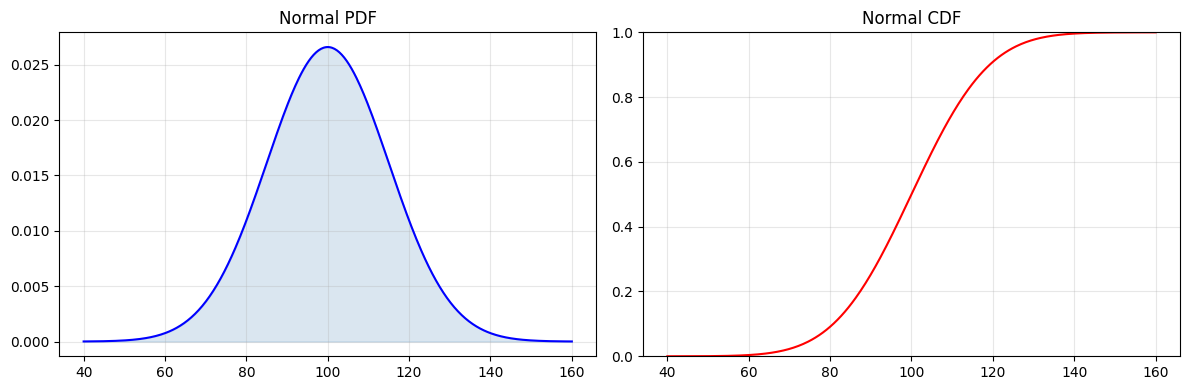

In [31]:
# Create a Normal distribution with mean=100 and std=15
dist = Normal(100.0, 15.0)

# Compute PDF/CDF values for a range of x
x = np.linspace(40, 160, 400)
pdf = np.array([float(dist.PDF(float(v))) for v in x])
cdf = np.array([float(dist.CDF(float(v))) for v in x])

# The distribution comes with these properties built in and easily accessible
print(f"Mean={float(dist.Mean):.3f}, Std={float(dist.StandardDeviation):.3f}")
print(f"P(X<120)={float(dist.CDF(120.0)):.4f}")
print(f"Q(0.90)={float(dist.InverseCDF(0.90)):.4f}")

# Plot the PDF and CDF
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(x, pdf, 'b-')
ax[0].fill_between(x, pdf, color='steelblue', alpha=0.2)
ax[0].set_title('Normal PDF')
ax[0].grid(alpha=0.3)

ax[1].plot(x, cdf, 'r-')
ax[1].set_title('Normal CDF')
ax[1].set_ylim(0,1)
ax[1].grid(alpha=0.3)

plt.tight_layout()

## Example 2: Build a BestFit DataFrame
Now we will show how to move raw values into a BestFit `DataFrame`.

Why this matters:
- `DataFrame` is the core input object used by BestFit analyses.
- It stores observations with metadata (index/year, type, plotting position).
- The same structure later supports exact, uncertain, interval, and threshold data types.

When working with BestFit and Numerics methods, we must pass them .NET arrays and data types. We must be careful when defining our variables and passing them back and forth. Below we first define our synthetic data in Python. Then we pass it to the BestFit DataFrame, converting it to ints and floats. To print our results at the end we have to convert the .NET DataFrame back to a Python data type to access the elements. It is a little confusing and can seem redundant at first, but as we continue with this demo, we will get better at switching between types and cut out some unnecessary middle steps.

Example 3, the Gumbel Flood-Frequency Workflow, also performs this DataFrame construction step. We will go more in depth about the DataFrame and the data types it accepts in notebook 01.

In [32]:
# Generate synthetic data
lognormal = LogNormal(1.0, 0.5) 
# Numerics method for generating random data from a distribution (available for all Numerics distributions)
lognormal_data = lognormal.GenerateRandomValues(20,123) 

# Define empty DataFrame
lognormal_df = DataFrame()
# Define a start year for the data series
start = 2000

# Pass data to BestFit DataFrame
for i,value in enumerate(lognormal_data):
    lognormal_df.ExactSeries.Add(ExactData(start + i, float(value))) # We must pass ExactData objects to the ExactSeries object

# To print the contents of the DataFrame, we can iterate over the ExactSeries and print each entry
print("Year\tValue")
for data_point in lognormal_df.ExactSeries:
    print(f"{data_point.Index}\t{data_point.Value:.4f}")

Year	Value
2000	18.0774
2001	19.0994
2002	5.2198
2003	8.1258
2004	4.2206
2005	17.7493
2006	11.6009
2007	19.5056
2008	19.5269
2009	9.7469
2010	7.9988
2011	24.3301
2012	108.3670
2013	7.7164
2014	17.4030
2015	12.6054
2016	9.4644
2017	2.8822
2018	7.2962
2019	7.4928


## Basic Example 3: Gumbel Flood-Frequency Workflow
Now we do a small end-to-end Gumbel workflow with a dataset that is more representative of block maxima. For this example we

1. Start with annual-maximum style values (stationary-ish center, right-skewed upper tail)
2. Build BestFit `DataFrame` and Gumbel model
3. Run MLE and graph the fitted distribution

For now, just follow along the flow from start to end. We will explore building BestFit models and using MLE in later notebooks.

In [33]:
# Annual-maximum style sample
annual_peaks = [
    7680, 8010, 8290, 8570, 8840,
    9130, 9410, 9680, 9950, 10240,
    10510, 10820, 11140, 11490, 11860,
    12250, 12690, 13160, 13680, 14260,
    14910, 15650, 16510, 17500, 18650,
]

# Build the DataFrame
df = DataFrame()
start_year = 1999

for i, value in enumerate(annual_peaks):
    df.ExactSeries.Add(ExactData(start_year + i, float(value)))

df.PlottingParameter = 0.0  # Weibull plotting positions
df.CalculatePlottingPositions()

print("BestFit DataFrame summary")
print(f"- Exact observations: {df.ExactSeries.Count}")
print(f"- Total record length: {df.TotalRecordLength()}")
print(f"- Plotting parameter: {df.PlottingParameter}")

print("First 5 records")
for i in range(min(5, df.ExactSeries.Count)):
    rec = df.ExactSeries[i]
    print(f"  index={rec.Index}, value={rec.Value:.1f}, p={rec.PlottingPosition:.4f}")

BestFit DataFrame summary
- Exact observations: 25
- Total record length: 25
- Plotting parameter: 0.0
First 5 records
  index=1999, value=7680.0, p=0.9615
  index=2000, value=8010.0, p=0.9231
  index=2001, value=8290.0, p=0.8846
  index=2002, value=8570.0, p=0.8462
  index=2003, value=8840.0, p=0.8077


### Build a BestFit Univariate Model
In RMC-BestFit, a model is any mathematical representation of a physical process that can be fitted to data. Models define the relationship between parameters and observations, specify prior distributions for Bayesian inference, and compute likelihood functions that measure how well parameter values explain the data [[3]](#3).

We will chose to use the Gumbel Distribution, a pre built model commonly used in flood frequency analysis.

In [34]:
# This is a UnivariateDistribution is a BestFit method -- there is a similar one implemented in Numerics
# UnivariateDistributionType is a Numerics method, used by BestFit
# Be sure you call the right methods from the right libraries and namespaces as there is a lot of overlap
# One wrong import can cause a lot of confusion and trouble!
gumbel_model = UnivariateDistribution(df, UnivariateDistributionType.Gumbel)

print("BestFit model summary")
print(f"- Distribution type: {gumbel_model.Distribution.Type}")
print(f"- Display name: {gumbel_model.Distribution.DisplayName}")
print(f"- Number of parameters: {gumbel_model.NumberOfParameters}")

BestFit model summary
- Distribution type: Gumbel
- Display name: Gumbel (EVI)
- Number of parameters: 2


Fitted parameters
- location: 10392.9337
- scale: 2351.041087


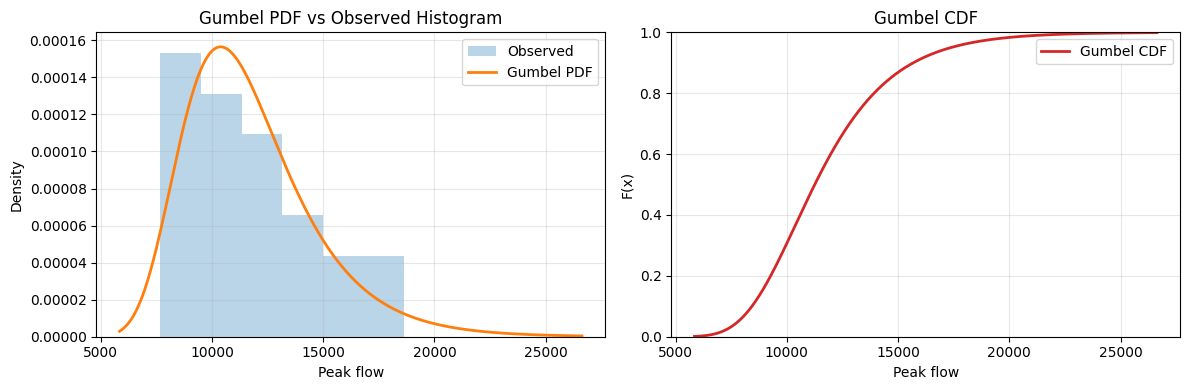

In [ ]:
# Estimate parameters using BestFit MLE
mle = MaximumLikelihood(gumbel_model)
mle.Estimate()

# Pull out the best parameters 
mle_params = np.array([float(v) for v in mle.BestParameterSet.Values], dtype=float)
loc = mle_params[0]
scale = mle_params[1]

# Fit our model using these best parameters
gumbel_model.SetParameterValues(convert_to_dotnet_array([loc, scale]))

# Use the fitted BestFit distribution directly for plotting
gumbel_fit = gumbel_model.Distribution

print("Fitted parameters")
print("- location:", round(loc, 4))
print("- scale:", round(scale, 6))

# Plot fitted PDF/CDF
x_low = float(gumbel_fit.InverseCDF(0.001))
x_high = float(gumbel_fit.InverseCDF(0.999))
x = np.linspace(x_low, x_high, 600)
pdf = np.array([float(gumbel_fit.PDF(float(v))) for v in x])
cdf = np.array([float(gumbel_fit.CDF(float(v))) for v in x])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# Our original observed data
ax[0].hist(annual_peaks, bins="auto", density=True, alpha=0.3, label="Observed")
ax[0].plot(x, pdf, lw=2, label="Gumbel PDF")
ax[0].set_title("Gumbel PDF vs Observed Histogram")
ax[0].set_xlabel("Peak flow")
ax[0].set_ylabel("Density")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(x, cdf, lw=2, color="tab:red", label="Gumbel CDF")
ax[1].set_title("Gumbel CDF")
ax[1].set_xlabel("Peak flow")
ax[1].set_ylabel("F(x)")
ax[1].set_ylim(0, 1)
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()

We can build empirical return-period points from out BestFit DataFrame outputs. We already asked BestFit to compute plotting positions with `df.CalculatePlottingPositions`. Now we map those positions to exceedance probabilities and return periods.

Plotting-position orientation used: exceedance
Gumbel quick-check quantiles
- Q2: 11254.62
- Q10: 15683.64
- Q50: 19566.55
- Q100: 21208.07


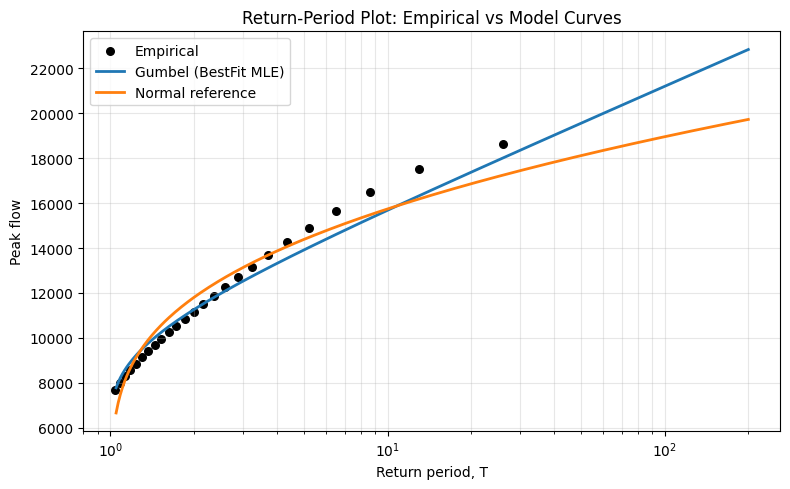

In [ ]:
# Extract data values and plotting positions
vals = [float(df.ExactSeries[i].Value) for i in range(df.ExactSeries.Count)]
p_plot = [float(df.ExactSeries[i].PlottingPosition) for i in range(df.ExactSeries.Count)]

# BestFit plotting positions can be stored as either exceedance or non-exceedance orientation
# Depending on context; detect orientation from value-probability correlation.
corr = Correlation.Pearson(convert_to_dotnet_array(vals), convert_to_dotnet_array(p_plot))

if corr < 0:
    p_exceed = [min(max(p, 1e-9), 1 - 1e-9) for p in p_plot]
    orientation = "exceedance"
else:
    p_exceed = [min(max(1.0 - p, 1e-9), 1 - 1e-9) for p in p_plot]
    orientation = "non-exceedance"

# Convert to return period T = 1 / p_exceed and sort for plotting.
# Pairs are (T, value) where T is the return period and value is the observed peak flow
pairs = sorted([(1.0 / p, v) for p, v in zip(p_exceed, vals)], key=lambda t: t[0])
# Pull out the return periods and values into separate arrays for plotting
T_emp = np.array([t for t, _ in pairs], dtype=float)
vals_emp = np.array([v for _, v in pairs], dtype=float)

# Model curves from Numerics distribution objects (already parameterized from BestFit MLE output)
T_grid = np.logspace(np.log10(1.05), np.log10(200), 300)
# Corresponding non-exceedance probabilities for the return periods
F_grid = 1.0 - 1.0 / T_grid

# Return period for Gumbel (already fitted Gumbel distribution with BestFit MLE parameters)
q_gumbel = np.array([float(gumbel_fit.InverseCDF(float(np.clip(f, 1e-6, 1 - 1e-6)))) for f in F_grid])

# Normal distribution for reference (mean and std from observed data)
normal_curve = Normal(float(np.mean(annual_peaks)), max(1e-6, float(np.std(annual_peaks, ddof=1))))
# Return period for Normal
q_norm = np.array([float(normal_curve.InverseCDF(float(np.clip(f, 1e-6, 1 - 1e-6)))) for f in F_grid])

plt.figure(figsize=(8, 5))
plt.scatter(T_emp, vals_emp, s=30, c="black", label="Empirical")
plt.plot(T_grid, q_gumbel, lw=2, label="Gumbel (BestFit MLE)")
plt.plot(T_grid, q_norm, lw=2, label="Normal reference")
plt.xscale("log")
plt.xlabel("Return period, T")
plt.ylabel("Peak flow")
plt.title("Return-Period Plot: Empirical vs Model Curves")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()

print(f"Plotting-position orientation used: {orientation}")
print("Gumbel quick-check quantiles")
for t in [2, 10, 50, 100]:
    f = 1.0 - 1.0 / t
    print(f"- Q{t}: {float(gumbel_fit.InverseCDF(float(f))):.2f}")


## Common Problems and Solutions
Going from .NET to Python is tricky! Here are some common errors and how to fix them. 

### 1. Runtime Not Loaded Error
Make sure you load the runtime BEFORE importing clr.

```python
# X WRONG - will fail
import clr
import pythonnet
pythonnet.load("coreclr")

# ✓ CORRECT - load runtime FIRST
import pythonnet
pythonnet.load("coreclr")
import clr
```

### 2. DLL Not Found
Verify the path in `dll_path` is correct and points to a dll that exists. If no dll exists, be sure that you have built the BestFit and Numerics solution.

### 3. Loading DLL More Than Once
When running multiple files at once, if they all load the DLLs with ```clr.AddReference(str(dll_path))``` it may fail with an error that they have  already been loaded. If this happens, add the statement below to check the assemblies and only load BestFit or Numerics if it is not already loaded. The code below doesn't output anything, but you'll know it worked if it runs without the failure error of loading multiple DLLS. This error shouldn't happened within these notebooks because they all have separate kernels. It would happen if you were trying to run multiple Python files all at once where each one loads the same DLL. In each of these files you would replace how you were originally loading the DLL with the chunk below.

```python
# Needed to access the assemblies
from System import AppDomain

assemblies = AppDomain.CurrentDomain.GetAssemblies()
assembly_names = [assembly.GetName().Name for assembly in assemblies]
if 'Numerics' not in assembly_names:
    clr.AddReference(str(dll_path))
```
The same chunk works if you replace 'Numerics' with 'RMC.BestFit'.
Better safe than sorry!

### 4. Array Type Mismatch
Check that you're using .NET arrays where required.

```python
# X WRONG - Python list
data = [1, 2, 3]
dist.LogLikelihood(data)  # Error!

# ✓ CORRECT - .NET array
data = Array[Double]([1, 2, 3])
dist.LogLikelihood(data)  # Works!
```

### 5. Accessing .NET Properties
```python
# X WRONG - trying to call a property
mean_value = dist.Mean()  # Error!

# ✓ CORRECT - properties don't use parentheses
mean_value = dist.Mean
```
## Summary
Congratulations! You've finished the first notebook in this demo! You are well on your way to mastering BestFit in Python.

You've learned:     
$\checkmark$ Locating or building the RMC.BestFit.dll and Numerics.dll      
$\checkmark$ Loading the correct .NET run time      
$\checkmark$ Building a basic normal distribution example       
$\checkmark$ Using BestFit's DataFrame method       
$\checkmark$ How to build and use a basic BestFit Model     
$\checkmark$ How to fix common troubleshooting steps        

## Exercises
1. Change runtime load from `netfx` to `coreclr` in a .NET 6 build environment.
2. Replace synthetic peaks with a real gauge CSV.
3. Add one more distribution and compare its CDF to Normal and Gumbel.

## References
<a id="1">[1]</a>
U.S. Army Corps of Engineers, Risk Management Center, *Flood Hazard Analysis Using RMC BestFit and RFA Software*, DLS-114 workshop, Mar. 2026, Version 1. Unpublished training materials.

<a id="2">[2]</a>
Microsoft, “Assemblies in .NET,” *Microsoft Learn* [Online]. Available: https://learn.microsoft.com/en-us/dotnet/standard/assembly/

<a id="3">[3]</a>
USACE Risk Management Center, *RMC-BestFit (Version 2.0 Beta)* [Software]. GitHub, 2025. Available: https://github.com/USACE-RMC/RMC-BestFit